## Classification: "diamonds" dataset

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split. (if dataset is unbalanced, use stratify)
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set (binary encoding, one-hot encoding, cyclic encoding)
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting
9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score (bonus: plot precision/recall/f1)
12. Find and plot most important features


In questo esempio, vogliamo stimare la variabile "cut" che è il livello di lucentezza di un diamante ("Fair", "Good", "Premium", etc.)

---

In [1]:
# 1. load data
import pandas as pd

df = pd.read_csv("regression_diamonds.csv")

In [2]:
#2. visualize data (EDA)
df

,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
# Controlliamo i tipi delle colonne e se ci sono valori nulli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   depth    53902 non-null  float64
 6   table    53940 non-null  float64
 7   price    53940 non-null  int64  
 8   x        53940 non-null  float64
 9   y        53940 non-null  float64
 10  z        53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
# Get column info with types and unique values

def get_column_info(df):
    """
    Returns a summary DataFrame with dtypes, null counts, 
    unique values for objects, and min/max for numeric columns.
    """
    summary_list = []
    
    for col in df.columns:

        # Basic info
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        non_null_count = df[col].notnull().sum()
        
        unique_values = df[col].unique().tolist()
        min_val = None
        max_val = None
        
        # Info for numeric columns (Int/Float)
        if pd.api.types.is_numeric_dtype(dtype):
            min_val = df[col].min()
            max_val = df[col].max()
        else: # Sort categorical unique values
            unique_values = sorted(unique_values)
            
        summary_list.append({
            'Column': col,
            'Type': dtype,
            'Nulls': null_count,
            'Non-Nulls': non_null_count,
            'Unique Count': df[col].nunique(),
            'Unique Values': unique_values,
            'Min': min_val,
            'Max': max_val
        })
    
    return pd.DataFrame(summary_list).sort_values(by='Type')

get_column_info(df)

,Column,Type,Nulls,Non-Nulls,Unique Count,Unique Values,Min,Max
0,id,int64,0,53940,53940,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.0,53940.00
7,price,int64,0,53940,11602,"[326, 327, 334, 335, 336, 337, 338, 339, 340, ...",326.0,18823.00
1,carat,float64,0,53940,273,"[0.23, 0.21, 0.29, 0.31, 0.24, 0.26, 0.22, 0.3...",0.2,5.01
5,depth,float64,38,53902,184,"[61.5, 59.8, 56.9, 62.4, 63.3, 62.8, 62.3, 61....",43.0,79.00
6,table,float64,0,53940,127,"[55.0, 61.0, 65.0, 58.0, 57.0, 56.0, 54.0, 62....",43.0,95.00
8,x,float64,0,53940,554,"[3.95, 3.89, 4.05, 4.2, 4.34, 3.94, 4.07, 3.87...",0.0,10.74
9,y,float64,0,53940,552,"[3.98, 3.84, 4.07, 4.23, 4.35, 3.96, 4.11, 3.7...",0.0,58.90
10,z,float64,0,53940,375,"[2.43, 2.31, 2.63, 2.75, 2.48, 2.47, 2.53, 2.4...",0.0,31.80
2,cut,object,0,53940,5,"[Fair, Good, Ideal, Premium, Very Good]",NaN,NaN
3,color,object,0,53940,7,"[D, E, F, G, H, I, J]",NaN,NaN


In [6]:
# Check just the categorical columns

def get_all_categories(df):
    """Get names and unique values for every column with type 'object'"""

    obj_cols = df.select_dtypes(include=['object']).columns
    data = []

    for col in obj_cols:
        data.append({
            'column_name': col,
            'unique_values': df[col].unique().tolist(),
            'value_count': len(df[col].unique()),
        })
    
    return pd.DataFrame(data)

get_all_categories(df)

,column_name,unique_values,value_count
0,cut,"[Ideal, Premium, Good, Very Good, Fair]",5
1,color,"[E, I, J, H, F, G, D]",7
2,clarity,"[SI2, SI1, VS1, VS2, VVS2, VVS1, I1, IF]",8


In [7]:
# Controlliamo meglio se ci sono valori nulli
df.isna().sum()

id          0
carat       0
cut         0
color       0
clarity     0
depth      38
table       0
price       0
x           0
y           0
z           0
dtype: int64

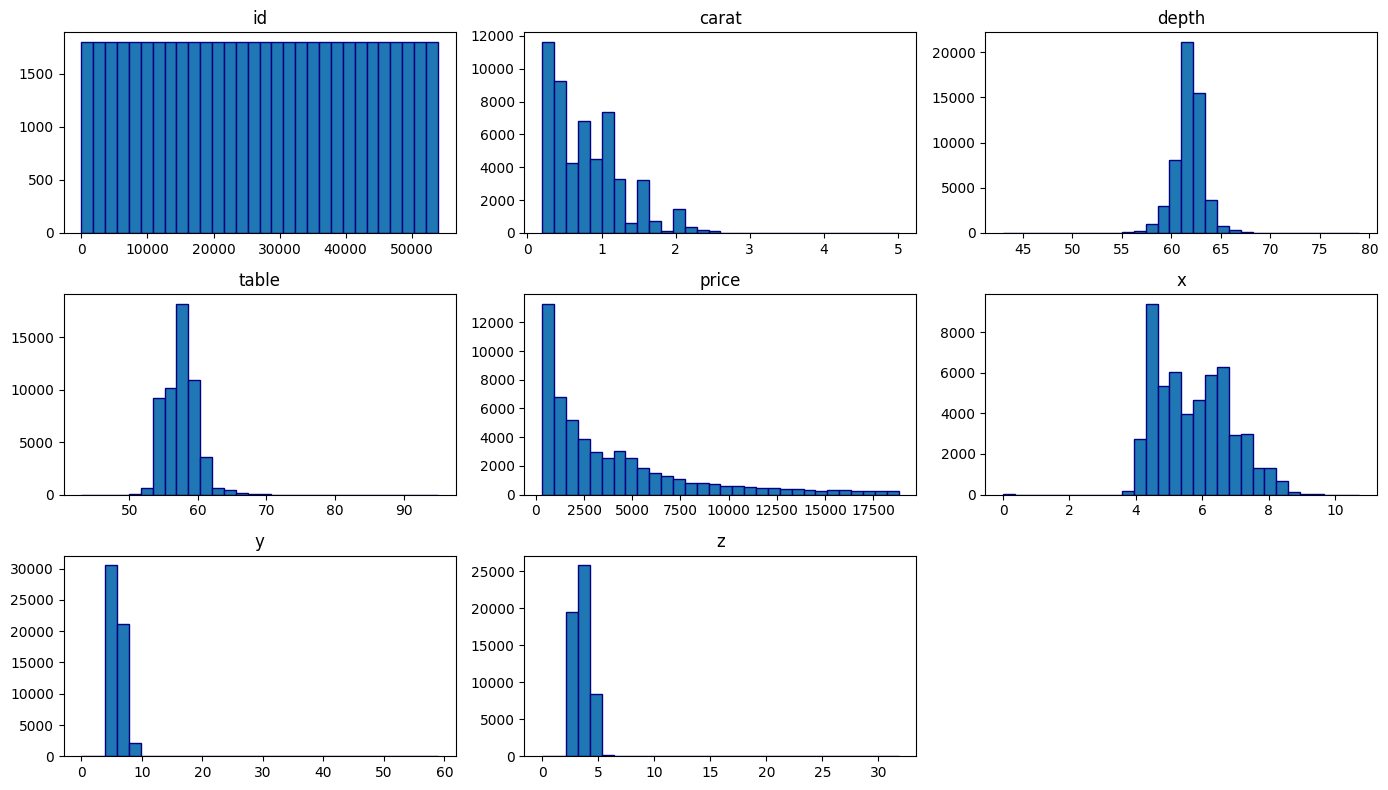

In [8]:
import matplotlib.pyplot as plt

def plot_histograms(df):
    '''Print histogram for all columns'''
    df.hist(figsize=(14, 8), bins=30, edgecolor='navy', grid=False)
    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [9]:
# 3. Clean data: remove columns and/or rows

df_clean = df.copy()

# Remove entire 'id' column because it's irrelevant for predictions:
df_clean = df_clean.drop(columns=["id"])

# Remove rows with null values in a certain column:
# (skip this for now because we will be filling them with the column average)
# df_clean = df_clean.dropna(subset=["depth"])

df_clean

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [10]:
# 4. X/y Split

# 'cut' è la variabile che dobbiamo stimare con il modello di classificazione
y = df_clean["cut"]
X = df_clean.drop(columns=["cut"])

In [11]:
# 5. train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Dati di train:", len(X_train))
print("Dati di test:", len(X_test))

Dati di train: 43152
Dati di test: 10788


In [12]:
# 6. Fill/Scale/Encode Data: apply this only to the training set, then use those same parameters to transform the test set

In [12]:
# In this dataset, the column 'depth' has some missing values:

# 30 missing values in the training set:
X_train.isna().sum()

carat       0
color       0
clarity     0
depth      30
table       0
price       0
x           0
y           0
z           0
dtype: int64

In [13]:
# 8 missing values in the test set:
X_test.isna().sum()

carat      0
color      0
clarity    0
depth      8
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [14]:
# 6.1 Fill missing values using the mean/median/mode (must be calculated from the training set only)

X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

average_depth = X_train_filled["depth"].mean()

X_train_filled["depth"] = X_train_filled["depth"].fillna(average_depth) # Fill the column on the TRAIN set
X_test_filled["depth"] = X_test_filled["depth"].fillna(average_depth)   # Fill the column on the TEST set

# Check that there are no more missing values
X_train_filled.isna().sum()

carat      0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [15]:
# 6.2 Encode a column manually

X_train_encoded = X_train_filled.copy()
X_test_encoded = X_test_filled.copy()

# Encode "clarity column"

clarity_encoding = {
  'IF': 8,
  'VVS1': 7,
  'VVS2': 6,
  'VS1': 5,
  'VS2': 4,
  'SI1': 3,
  'SI2': 2,
  'I1': 1,
}

X_train_encoded['clarity'] = X_train_encoded['clarity'].map(clarity_encoding)
X_test_encoded['clarity'] = X_test_encoded['clarity'].map(clarity_encoding)

X_train_encoded

,carat,color,clarity,depth,table,price,x,y,z
25663,2.03,J,5,62.5,57.0,14579,8.14,8.08,5.06
40693,0.41,F,7,62.3,56.0,1157,4.77,4.79,2.98
5061,0.34,F,2,60.0,58.0,574,4.58,4.55,2.74
23427,1.32,G,6,62.3,57.0,11419,6.96,7.04,4.36
46788,0.50,E,5,58.2,61.0,1806,5.19,5.22,3.03
...,...,...,...,...,...,...,...,...,...
47612,0.53,G,6,60.4,55.0,1881,5.26,5.30,3.19
37055,0.43,G,3,62.9,55.0,968,4.87,4.83,3.05
197,0.70,E,3,61.0,58.0,2777,5.78,5.72,3.51
1690,0.52,E,8,61.1,57.0,3033,5.17,5.21,3.17


In [16]:
# Encode 'y' target variable ("cut")

cut_encoding = {
  'Ideal': 5,
  'Premium': 4,
  'Very Good': 3,
  'Good': 2,
  'Fair': 1,
}

y_train_encoded = y_train.copy().map(cut_encoding)
y_test_encoded = y_test.copy().map(cut_encoding)

# Print the column, notice that the type has been converted from 'object' to 'int64'
y_train_encoded

25663    5
40693    5
5061     4
23427    5
46788    2
        ..
47612    5
37055    5
197      4
1690     5
15957    4
Name: cut, Length: 43152, dtype: int64

In [17]:
# Use one-hot encoding to encode a categorical column
# This is an alternative to ordinal encoding for non-ordered categories
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(X_train: pd.DataFrame, X_test: pd.DataFrame, columns_to_encode: list[str]) -> tuple[pd.DataFrame]:
    """Applies one-hot encoding to the specified columns"""

    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()

    one_hot_encoder = OneHotEncoder(
        sparse_output=False,  # Output a full matrix of 0 and 1 instead of a lightweight "sparse" matrix of just ones
        handle_unknown="ignore",
    ).set_output(transform="pandas") # Otherwise the encoder outputs a numpy array instead of a pandas dataframe

    new_encoded_columns = one_hot_encoder.fit_transform(X_train_encoded[columns_to_encode])

    # Add the new columns to the original TRAIN dataframe
    X_train_encoded = pd.concat(
        [
            X_train_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )

    # Add the new columns to the original dataframe
    new_encoded_columns = one_hot_encoder.transform(X_test_encoded[columns_to_encode])
    X_test_encoded = pd.concat(
        [
            X_test_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )  # Add the new columns to the original TEST dataframe

    # Remove original unencoded columns
    X_train_encoded = X_train_encoded.drop(columns=columns_to_encode)
    X_test_encoded = X_test_encoded.drop(columns=columns_to_encode)

    return X_train_encoded, X_test_encoded


X_train_1h_encoded, X_test_1h_encoded = one_hot_encode(X_train_encoded, X_test_encoded, columns_to_encode=["color"])

# Print result
X_train_1h_encoded

,carat,clarity,depth,table,price,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,2.03,5,62.5,57.0,14579,8.14,8.08,5.06,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.41,7,62.3,56.0,1157,4.77,4.79,2.98,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.34,2,60.0,58.0,574,4.58,4.55,2.74,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.32,6,62.3,57.0,11419,6.96,7.04,4.36,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.50,5,58.2,61.0,1806,5.19,5.22,3.03,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,0.53,6,60.4,55.0,1881,5.26,5.30,3.19,0.0,0.0,0.0,1.0,0.0,0.0,0.0
43148,0.43,3,62.9,55.0,968,4.87,4.83,3.05,0.0,0.0,0.0,1.0,0.0,0.0,0.0
43149,0.70,3,61.0,58.0,2777,5.78,5.72,3.51,0.0,1.0,0.0,0.0,0.0,0.0,0.0
43150,0.52,8,61.1,57.0,3033,5.17,5.21,3.17,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# 6.3 Scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_1h_encoded)
X_test_scaled = scaler.transform(X_test_1h_encoded)

X_train_scaled

,carat,clarity,depth,table,price,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,2.614309,0.577224,0.522613,-0.203129,2.677162,2.154961,2.046985,2.154662,-0.379205,-0.472989,-0.463092,-0.514322,-0.42622,-0.335039,4.312393
1,-0.820948,1.792089,0.383291,-0.652068,-0.696699,-0.859106,-0.823995,-0.791343,-0.379205,-0.472989,2.159396,-0.514322,-0.42622,-0.335039,-0.231890
2,-0.969385,-1.245073,-1.218913,0.245809,-0.843247,-1.029039,-1.033428,-1.131267,-0.379205,-0.472989,2.159396,-0.514322,-0.42622,-0.335039,-0.231890
3,1.108734,1.184657,0.383291,-0.203129,1.882839,1.099590,1.139441,1.163218,-0.379205,-0.472989,-0.463092,1.944306,-0.42622,-0.335039,-0.231890
4,-0.630100,0.577224,-2.472811,1.592626,-0.533562,-0.483466,-0.448761,-0.720526,-0.379205,2.114213,-0.463092,-0.514322,-0.42622,-0.335039,-0.231890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,-0.566484,1.184657,-0.940268,-1.101007,-0.514709,-0.420859,-0.378950,-0.493910,-0.379205,-0.472989,-0.463092,1.944306,-0.42622,-0.335039,-0.231890
43148,-0.778537,-0.637641,0.801257,-1.101007,-0.744208,-0.769668,-0.789090,-0.692199,-0.379205,-0.472989,-0.463092,1.944306,-0.42622,-0.335039,-0.231890
43149,-0.205994,-0.637641,-0.522302,0.245809,-0.289483,0.044220,-0.012442,-0.040678,-0.379205,2.114213,-0.463092,-0.514322,-0.42622,-0.335039,-0.231890
43150,-0.587690,2.399521,-0.452641,-0.203129,-0.225133,-0.501353,-0.457487,-0.522237,-0.379205,2.114213,-0.463092,-0.514322,-0.42622,-0.335039,-0.231890


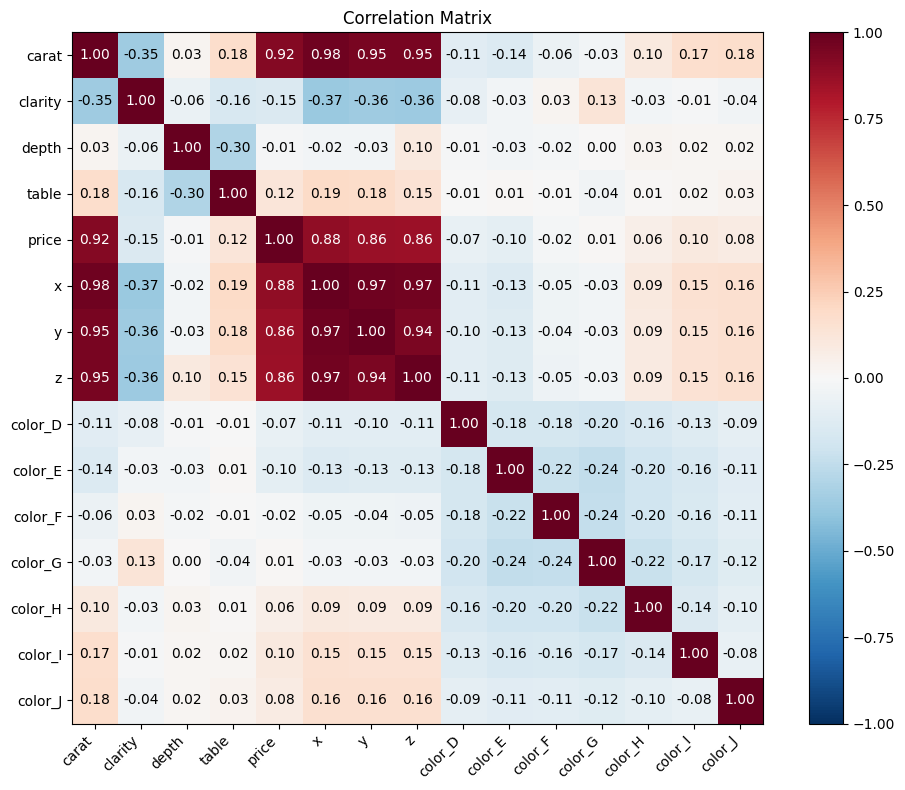

In [19]:
# 7. Check Correlation Matrix on the scaled/encoded training data

def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

show_correlation_matrix(X_train_scaled)

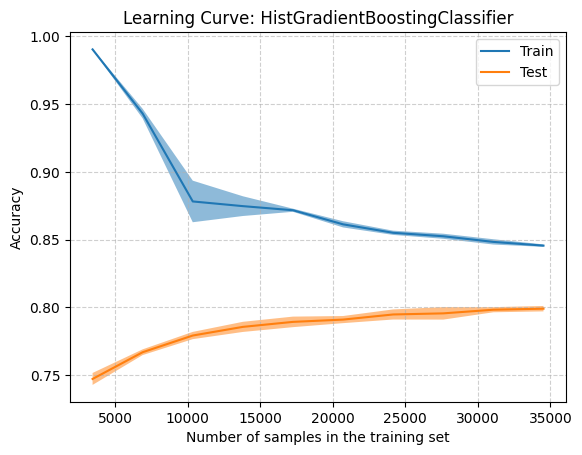

In [21]:
# 8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

from sklearn.ensemble import HistGradientBoostingClassifier

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()


model = HistGradientBoostingClassifier()
plot_learning_curve(model, X_train_scaled, y_train_encoded, classification=True)

In [16]:
# 9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

model = HistGradientBoostingClassifier()
grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_encoded)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}
Best score: 0.8007971427470544


In [34]:
# 10. Train Final Model: Retrain the model on the entire training set using the best parameters found

from sklearn.ensemble import HistGradientBoostingClassifier

best_params = {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 100, 'max_leaf_nodes': 63, 'min_samples_leaf': 50}

best_model = HistGradientBoostingClassifier(**best_params) # Pass a dictionary as parameters
best_model.fit(X_train_scaled, y_train_encoded)
y_pred = best_model.predict(X_test_scaled)

In [ ]:
# 11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score

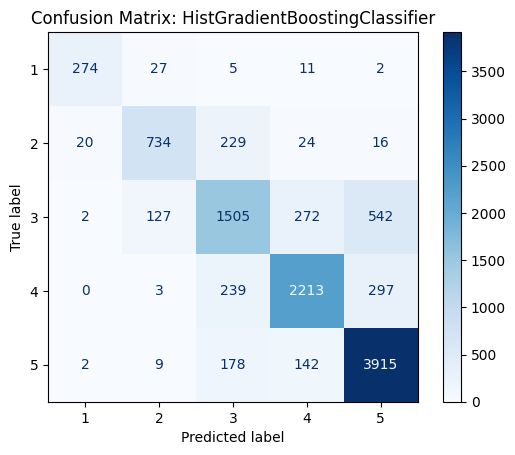

In [35]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()

show_confusion_matrix(best_model, y_test_encoded, y_pred)

In [36]:
# Precision/recall/F1-score

from sklearn.metrics import classification_report

def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose()

get_classification_report(y_test_encoded, y_pred)

,precision,recall,f1-score,support
1,0.919463,0.858934,0.888169,319.000000
2,0.815556,0.717498,0.763391,1023.000000
3,0.698052,0.614788,0.653779,2448.000000
4,0.831330,0.804142,0.817510,2752.000000
5,0.820411,0.922044,0.868263,4246.000000
accuracy,0.800983,0.800983,0.800983,0.800983
macro avg,0.816962,0.783481,0.798222,10788.000000
weighted avg,0.797899,0.800983,0.797290,10788.000000


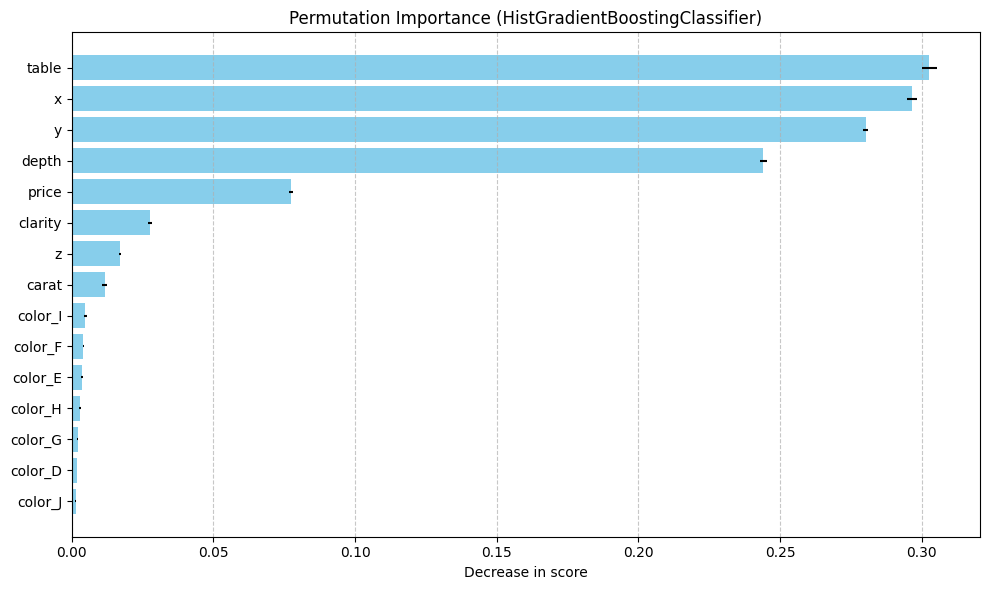

,Feature,Importance_Mean,Importance_Std
3,table,0.302609,0.002638
5,x,0.296607,0.001831
6,y,0.280168,0.000956
2,depth,0.244105,0.001154
4,price,0.077382,0.000608
1,clarity,0.027670,0.000758
7,z,0.016963,0.000337
0,carat,0.011573,0.000767
13,color_I,0.004839,0.000420
10,color_F,0.004120,0.000226


In [39]:
# Find and plot most important features

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def check_permutation_importance(trained_model, X_test, y_test, n_repeats):
    """
    Calculates and plots permutation importance for a trained model
    """
    # Calculate importance
    result = permutation_importance(trained_model, X_test, y_test, n_repeats=n_repeats, n_jobs=-1)
    
    # Organize into a DataFrame
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": result.importances_mean,
        "Importance_Std": result.importances_std
    }).sort_values(by="Importance_Mean", ascending=False)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance_Mean"], 
             xerr=importance_df["Importance_Std"], color='skyblue')
    plt.xlabel("Decrease in score")
    plt.title(f"Permutation Importance ({trained_model.__class__.__name__})")
    plt.gca().invert_yaxis()  # Put highest importance at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df


check_permutation_importance(best_model, X_train_scaled, y_train_encoded, n_repeats=5)

In [ ]:
# ROC curve and AUC score

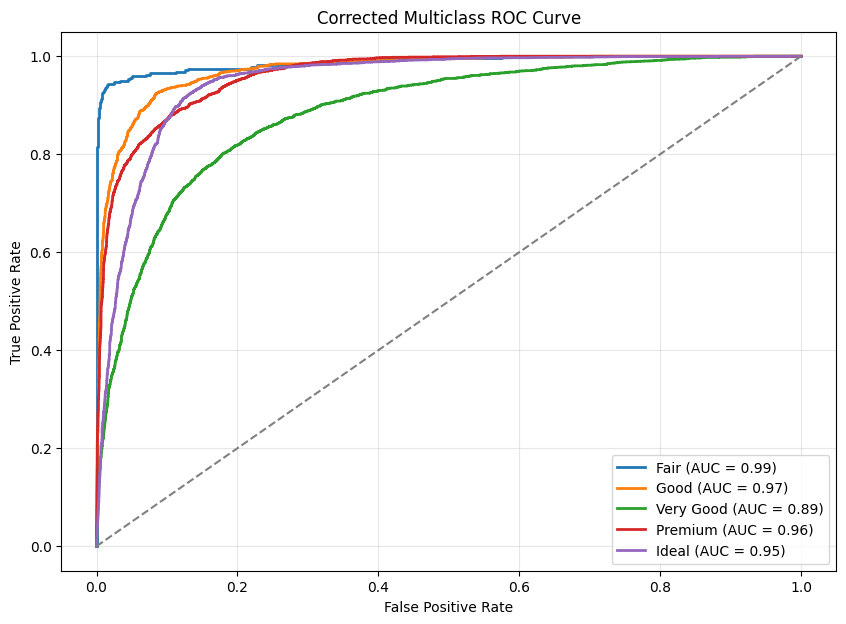

AUC: 0.7302983716962922


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve_binary(model, X_test, y_test):
    """
    Plots a single ROC curve for binary classification.
    """
    # Get scores (probabilities or decision function)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return auc


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

def plot_roc_curve_multiclass(model, X_test, y_test, class_names: dict[int, str]):
    y_score = model.predict_proba(X_test)
    
    # Create reverse map: {'cat_a': 1, 'cat_b': 2, ...}
    reverse_map = {v: k for k, v in class_names.items()}
    
    # Convert y_test to numbers if they are strings
    # If y_test is already numbers, this won't hurt
    y_test_numeric = [reverse_map.get(label, label) for label in y_test]
    
    lb = LabelBinarizer()
    lb.fit(model.classes_) # list[int]
    y_test_binarized = lb.transform(y_test_numeric)
    
    plt.figure(figsize=(10, 7))
    
    for i, class_val in enumerate(model.classes_):
        # Check if the class exists in y_test, if not then skip it
        if np.any(y_test_binarized[:, i]):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
            auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
            
            name = class_names.get(class_val, f"Class {class_val}")
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.2f})')
        else:
            print(f"Skipping Class {class_val}: No positive samples found in this dataset slice.")

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for multiple classes')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    # Note: this will also fail if a class is missing
    # Use 'labels' param to only calculate for classes actually present
    # present_classes = np.unique(y_test)
    # return roc_auc_score(y_test, y_score, multi_class='ovr', average='macro', labels=present_classes)


class_names = {1: 'Fair', 2: 'Good', 3: 'Very Good', 4: 'Premium', 5: 'Ideal'}
plot_roc_curve_multiclass(best_model, X_test_scaled, y_test, class_names)
# print("AUC:", auc)